In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
df= pd.read_csv("datasets/maaza_from_dump.csv")
df

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,723246245027,"Maaza, Mango Juice",House Of Spices,NaN,united-states,NaN,NaN,NaN,unknown,4.0,unknown,"Water, pure mango pulp, sugar, citric acid, na...",12.8,56.0
1,755270000310,Jus De Litchi Maaza 1L Pay Bas,Maaza,jus-de-litchi,france,NaN,NaN,NaN,c,NaN,NaN,NaN,NaN,NaN
2,755270000358,Jus De Guana Bana (corossol) Maaza 1L Pay Bas,Kern's Nectar,NaN,france,bouteille,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
3,755270000365,Jus De Mangue 1L,Maaza,"plant-based-foods-and-beverages, beverages, pl...",france,NaN,NaN,NaN,e,4.0,NaN,"eau, purée de mangue (21%), sucre, acidulant: ...",NaN,NaN
4,755270000518,Maaza Lychee,Maaza,"beverages, sweetened-beverages",france,NaN,NaN,NaN,e,4.0,NaN,"eau, purée de litchi (18%), sucre, stabilisant...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,6611113,Maaza mango 350ml,Maaza,NaN,netherlands,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
120,6614892,Maaza Mango GST,Maaza,NaN,netherlands,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
121,6605358,Maaza tropical,Maaza,NaN,netherlands,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
122,6611558,Maaza Tropical,Maaza,NaN,netherlands,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN


In [3]:
df.dtypes

code                             int64
product_name                    object
brands                          object
categories_tags                 object
countries_tags                  object
packaging_tags                  object
stores                          object
purchase_places                 object
nutriscore_grade                object
nova_group                     float64
ecoscore_grade                  object
ingredients_text                object
nutriments.sugars_100g         float64
nutriments.energy-kcal_100g    float64
dtype: object

In [4]:
df.code[df.duplicated()]

Series([], Name: code, dtype: int64)

## Data Cleaning

In [5]:
df.isnull().sum()

code                             0
product_name                     2
brands                           9
categories_tags                 71
countries_tags                   4
packaging_tags                 108
stores                         121
purchase_places                118
nutriscore_grade                 0
nova_group                      81
ecoscore_grade                 112
ingredients_text                78
nutriments.sugars_100g         106
nutriments.energy-kcal_100g    103
dtype: int64

In [6]:
df['product_name'] = df['product_name'].fillna('unknown')
df['brands'] = df['brands'].fillna('unknown')
df['categories_tags'] = df['categories_tags'].fillna('unknown')
df['countries_tags'] = df['countries_tags'].fillna('unknown')
df['packaging_tags'] = df['packaging_tags'].fillna('unknown')
df['stores'] = df['stores'].fillna('unknown')
df['purchase_places'] = df['purchase_places'].fillna('unknown')
df['ecoscore_grade'] = df['ecoscore_grade'].fillna('unknown')
df['ingredients_text'] = df['ingredients_text'].fillna('unknown')


In [7]:
df.rename(columns={"nutriments.sugars_100g":"nutriments_sugar_100g"},inplace=True)
df.rename(columns={"nutriments_energy-kcal_100g":"nutriments_energy_kcal_100g"},inplace=True)
df

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments_sugar_100g,nutriments.energy-kcal_100g
0,723246245027,"Maaza, Mango Juice",House Of Spices,unknown,united-states,unknown,unknown,unknown,unknown,4.0,unknown,"Water, pure mango pulp, sugar, citric acid, na...",12.8,56.0
1,755270000310,Jus De Litchi Maaza 1L Pay Bas,Maaza,jus-de-litchi,france,unknown,unknown,unknown,c,NaN,unknown,unknown,NaN,NaN
2,755270000358,Jus De Guana Bana (corossol) Maaza 1L Pay Bas,Kern's Nectar,unknown,france,bouteille,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
3,755270000365,Jus De Mangue 1L,Maaza,"plant-based-foods-and-beverages, beverages, pl...",france,unknown,unknown,unknown,e,4.0,unknown,"eau, purée de mangue (21%), sucre, acidulant: ...",NaN,NaN
4,755270000518,Maaza Lychee,Maaza,"beverages, sweetened-beverages",france,unknown,unknown,unknown,e,4.0,unknown,"eau, purée de litchi (18%), sucre, stabilisant...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,6611113,Maaza mango 350ml,Maaza,unknown,netherlands,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
120,6614892,Maaza Mango GST,Maaza,unknown,netherlands,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
121,6605358,Maaza tropical,Maaza,unknown,netherlands,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
122,6611558,Maaza Tropical,Maaza,unknown,netherlands,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN


### Observation

* Data cleaning was performed
* Missing values were identify
* NaN values were replaced with "Unknown"
* Columns were renamed for better understanding

## Univariate Analysis

### Countries

In [8]:
df.countries_tags.unique()

raw_countries = df.countries_tags.str.split(',')
raw_countries

exploded = raw_countries.explode().str.strip()
exploded

0      united-states
1             france
2             france
3             france
4             france
           ...      
119      netherlands
120      netherlands
121      netherlands
122      netherlands
123      netherlands
Name: countries_tags, Length: 128, dtype: object

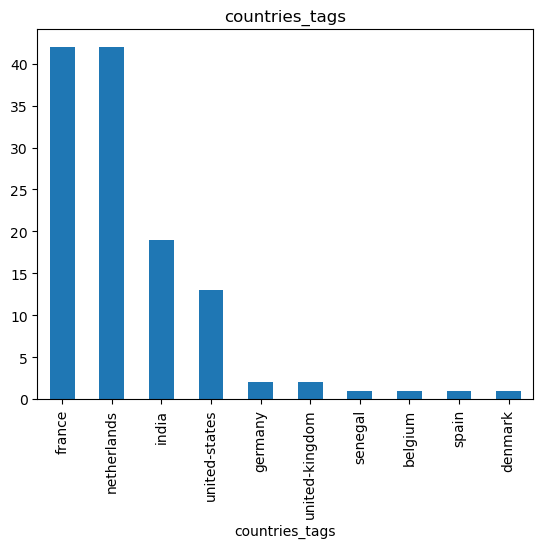

In [9]:
country_graph = exploded.value_counts().drop("unknown")
country_graph.plot(kind="bar",title="countries_tags")
plt.show()

### Categories

In [10]:
df.categories_tags.unique()

raw_categories = df.categories_tags.str.split(',')
raw_categories

exploded_categories = raw_categories.explode().str.strip()
exploded_categories

0                              unknown
1                        jus-de-litchi
2                              unknown
3      plant-based-foods-and-beverages
3                            beverages
                    ...               
119                            unknown
120                            unknown
121                            unknown
122                            unknown
123                            unknown
Name: categories_tags, Length: 317, dtype: object

In [11]:
exploded_categories.value_counts()

categories_tags
unknown                                  71
beverages                                49
sweetened-beverages                      30
beverages-and-beverages-preparations     28
plant-based-foods-and-beverages          27
plant-based-beverages                    26
fruit-based-beverages                    23
juices-and-nectars                       14
fruit-juices                             11
unsweetened-beverages                     4
fruit-nectars                             2
sweet-snacks                              1
snacks                                    1
confectioneries                           1
coconut-waters                            1
hot-beverages                             1
teas                                      1
desserts                                  1
mango-juice                               1
guava-juice-from-concentrate              1
aloe-vera-drinks                          1
Ready to serve fruit drink                1
Cooldrank       

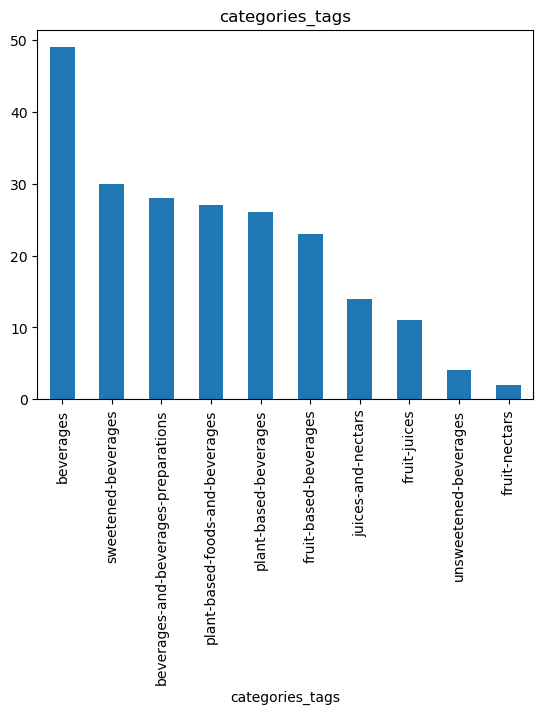

In [12]:
category_graph = exploded_categories.value_counts().drop("unknown").head(10)
category_graph.plot(kind="bar",title="categories_tags")
plt.show()

### Packaging

In [13]:
df.packaging_tags.unique()
df.packaging_tags.value_counts()

raw_packaging = df.packaging_tags.str.split(',')
raw_packaging

exploded_packaging = raw_packaging.explode().str.strip()
exploded_packaging


0        unknown
1        unknown
2      bouteille
3        unknown
4        unknown
         ...    
119      unknown
120      unknown
121      unknown
122      unknown
123      unknown
Name: packaging_tags, Length: 134, dtype: object

In [14]:
exploded_packaging.value_counts()

packaging_tags
unknown                 108
brick                     5
cardboard                 5
bottle                    4
plastic                   3
tetra-pak                 2
bouteille                 1
bouteille-plastique       1
canette-aluminium         1
paperboard                1
plastic-bottle            1
multilayer-composite      1
can                       1
Name: count, dtype: int64

In [15]:
exploded_packaging = exploded_packaging.str.replace('bouteille','bottle')
exploded_packaging = exploded_packaging.str.replace('bottle-plastique','bottle')
exploded_packaging = exploded_packaging.str.replace('plastic-bottle','bottle')
exploded_packaging = exploded_packaging.str.replace('canette-aluminium','can')
exploded_packaging = exploded_packaging.str.replace('tetra-pak','brick')
exploded_packaging = exploded_packaging.str.replace('paperboard','cardboard')

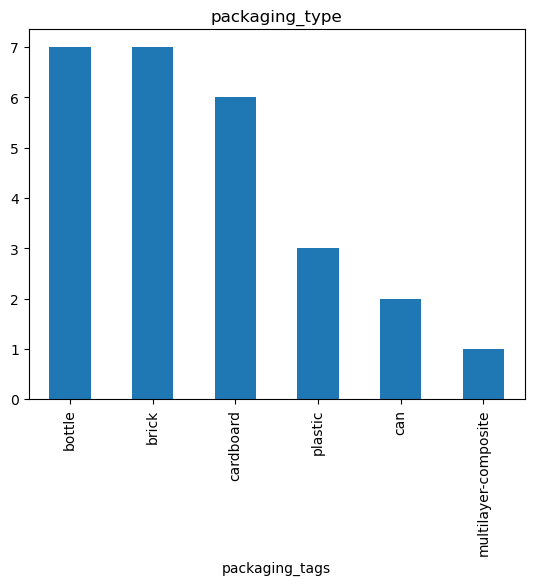

In [16]:
packaging_graph = exploded_packaging.value_counts().drop("unknown")
packaging_graph.plot(kind="bar", title="packaging_type")
plt.show()

### Stores

In [17]:
df.stores.value_counts()
#stores counts is not available


stores
unknown                                         121
Action                                            1
AZ sasu 45 rue Heurtault 93300 Aubervilliers      1
Auchan                                            1
Name: count, dtype: int64

### Purchase Places

In [18]:
df.purchase_places.unique()

raw_purchase_places = df.purchase_places.str.split(",")
raw_purchase_places

exploded_places = raw_purchase_places.explode().str.strip()
exploded_places



0      unknown
1      unknown
2      unknown
3      unknown
4      unknown
        ...   
119    unknown
120    unknown
121    unknown
122    unknown
123    unknown
Name: purchase_places, Length: 128, dtype: object

In [19]:
drop_elements = exploded_places[exploded_places=='unknown'].index
exploded_places = exploded_places.drop(drop_elements)

In [20]:
drop_elements1 = exploded_places[exploded_places==""].index
exploded_places = exploded_places.drop(drop_elements1)

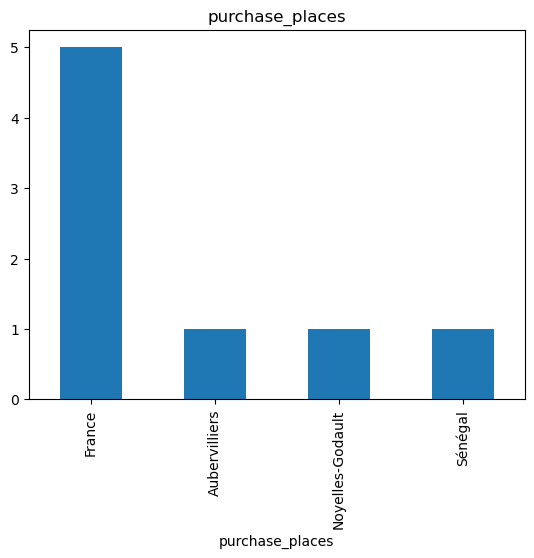

In [21]:
places_count = exploded_places.value_counts()

places_graph = places_count.plot(kind="bar",title="purchase_places")
plt.show()

### Nutriscore Grade

In [22]:
df.nutriscore_grade.unique()

raw_grade = df.nutriscore_grade.str.split(",")
raw_grade

exploded_grade = raw_grade.explode().str.strip()
exploded_grade



0      unknown
1            c
2      unknown
3            e
4            e
        ...   
119    unknown
120    unknown
121    unknown
122    unknown
123    unknown
Name: nutriscore_grade, Length: 124, dtype: object

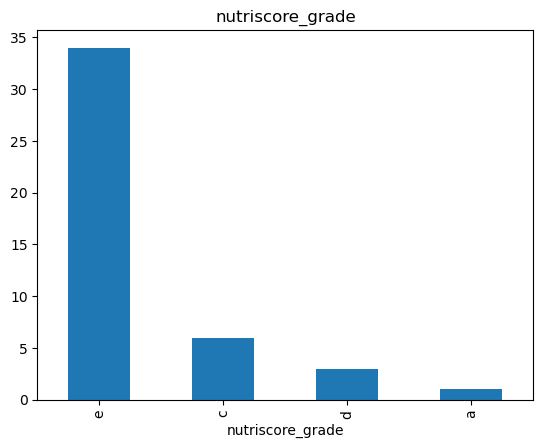

In [23]:
grade_graph = exploded_grade.value_counts().drop("unknown")
grade_graph.plot(kind="bar",title="nutriscore_grade")
plt.xticks(rotation=90)
plt.show()



In [24]:
df.nova_group.unique()

array([ 4., nan,  1.])

### Ecoscore Grade

In [25]:
df.ecoscore_grade.unique()

raw_ecoscore_grade = df.ecoscore_grade.str.split(",")
raw_ecoscore_grade

exploded_ecoscore_grade = raw_ecoscore_grade.explode().str.strip()
exploded_ecoscore_grade



0      unknown
1      unknown
2      unknown
3      unknown
4      unknown
        ...   
119    unknown
120    unknown
121    unknown
122    unknown
123    unknown
Name: ecoscore_grade, Length: 124, dtype: object

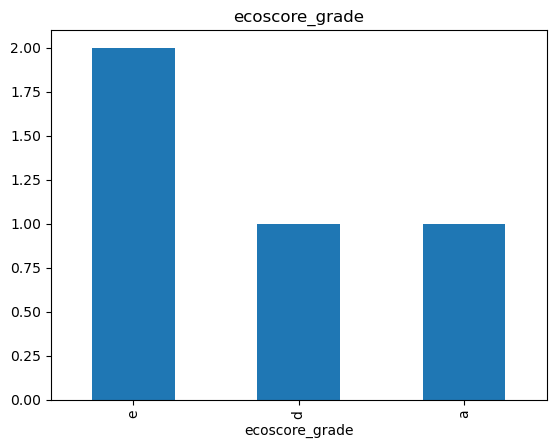

In [26]:
grade_graph = exploded_ecoscore_grade.value_counts().drop("unknown")
grade_graph.plot(kind="bar",title= "ecoscore_grade")
plt.show()

In [27]:
df.ingredients_text.unique()

array(['Water, pure mango pulp, sugar, citric acid, natural & artificial mango flavors, preservatives: sodium benzoate and potassium meta bi-sulphite. ascorbic acid, color fd & c yellow # 6.',
       'unknown',
       'eau, purée de mangue (21%), sucre, acidulant: acide citrique, aromes',
       'eau, purée de litchi (18%), sucre, stabilisant: xanthan, acidulant: acide citrique, arômes de litchi',
       'eau, purée de mangue (18%), sucre, acidulant: acide citrique, arômes de mangue,',
       'eau, purée de goyave (15%), sucre, acidulant: acide citrique, arômes, colorant: carmin.',
       'Eau, 25 % jus (purée de banane 10 % - pomme 10 % - ananas 2 % - jus de citron 2 %, pêche à base de concentré), sucre, acidifiant : acide citrique, arômes, colorant : B-carotène.',
       'Eau, purée de goyave (18%), sucre, acidulant : acide citrique, arômes, colorant : carmin.',
       'puree de goyave (ü 0 90), sucre, acjduldint• aci catmin.',
       'eau, purée de mangues (18%), sucre, acidulant : 

### Observation

* Analysis unique values in each column.
* Split multi-valued entries for better analysis.
* Applied explode() function to expand list values into separate rows.
* Removed "Unknown" values only for visualization.
* Created separate variables for modified data.
* Kept the original dataset unchanged.
* Prepared transformed data for effective visualization.


## Fetching data of India

In [28]:
india_data = df[df["countries_tags"].str.contains("india", na=False)]
india_data

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments_sugar_100g,nutriments.energy-kcal_100g
35,8901764092206,Maaza,"Mazza, The Coca-Cola Company","beverages-and-beverages-preparations, plant-ba...",india,unknown,unknown,unknown,e,4.0,unknown,"WATER, MANGO PULP (19.5%), SUGAR, ACIDITY REGU...",NaN,NaN
37,11017630,unknown,Maaza,unknown,india,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
40,8901764092305,Maaza Origina,HINDUSTAN COCA-COLA BEVERAGES PVT LTD.,"beverages-and-beverages-preparations, beverage...",india,unknown,unknown,unknown,e,4.0,unknown,"WATER, MANGO PULP (19.5%), SUGAR, ACIDITY REGU...",NaN,NaN
45,8901764175022,maaza,Coca cola,"beverages-and-beverages-preparations, beverage...",india,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
53,8901764092152,Maaza Original 1.75ltr,HINDUSTAN COCO-COLA BEVERAGES PVT.LTD,"beverages-and-beverages-preparations, beverage...",india,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
54,8901764092107,Maaza 1.5L,unknown,unknown,india,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
56,8901764092800,Maaza,Coca-Cola Company,"beverages-and-beverages-preparations, plant-ba...",india,unknown,unknown,unknown,d,4.0,unknown,"water, sugar, acidity regulator (330), salt, a...",7.0,32.0
57,8901764092329,Maaza,Cocacola,"beverages-and-beverages-preparations, beverage...",india,unknown,unknown,unknown,unknown,4.0,unknown,"Water, sugar, mango pulp (10.7%), acidity regu...",13.0,60.0
58,3948764092800,maaza,coco-cola,"beverages-and-beverages-preparations, beverage...",india,unknown,unknown,unknown,e,NaN,unknown,unknown,NaN,NaN
59,3948764175022,Maaza,Maaza,"beverages-and-beverages-preparations, plant-ba...",india,"multilayer-composite, tetra-pak",unknown,unknown,e,4.0,unknown,"water, mango pulp (11.5%). sugar, acidity regu...",NaN,NaN


In [29]:
india_data["product_name"].value_counts()

product_name
Maaza                     7
maaza                     4
unknown                   1
Maaza Origina             1
Maaza Original 1.75ltr    1
Maaza 1.5L                1
Fruit drink               1
Maaza Gold Tea            1
maazaaa                   1
Maaza can                 1
Name: count, dtype: int64

In [30]:
indian_products = india_data['product_name'].replace({
    'maaza':'Maaza', 
    'maazaaa':'Maaza' , 
    'Maaza Origina':'Maaza'
    })

In [31]:
product_count = indian_products.value_counts()
product_count

product_name
Maaza                     13
unknown                    1
Maaza Original 1.75ltr     1
Maaza 1.5L                 1
Fruit drink                1
Maaza Gold Tea             1
Maaza can                  1
Name: count, dtype: int64

### Observation

* India data contains 13 records for maaza.
* In packaging tags, Stores, Purchase places columns are dominated by unknown values.
* Due to large number of unknown value in several columns , those provide limited insights for visualization.

# Fetching data of France

In [35]:
france_data = df[df["countries_tags"].str.contains("france", na=False)]
france_data

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments_sugar_100g,nutriments.energy-kcal_100g
1,755270000310,Jus De Litchi Maaza 1L Pay Bas,Maaza,jus-de-litchi,france,unknown,unknown,unknown,c,NaN,unknown,unknown,NaN,NaN
2,755270000358,Jus De Guana Bana (corossol) Maaza 1L Pay Bas,Kern's Nectar,unknown,france,bouteille,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
3,755270000365,Jus De Mangue 1L,Maaza,"plant-based-foods-and-beverages, beverages, pl...",france,unknown,unknown,unknown,e,4.0,unknown,"eau, purée de mangue (21%), sucre, acidulant: ...",NaN,NaN
4,755270000518,Maaza Lychee,Maaza,"beverages, sweetened-beverages",france,unknown,unknown,unknown,e,4.0,unknown,"eau, purée de litchi (18%), sucre, stabilisant...",NaN,NaN
5,755270000549,Maaza Tropical Fles,Maaza,unknown,france,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
6,755270000556,Maaza Guava,Maaza,unknown,france,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
7,755270000563,Mango,maaza,unknown,france,unknown,unknown,unknown,unknown,4.0,unknown,"eau, purée de mangue (18%), sucre, acidulant: ...",NaN,NaN
8,8718226320025,Maaza guava,Maaza,"beverages, sweetened-beverages",france,unknown,unknown,unknown,e,4.0,unknown,"eau, purée de goyave (15%), sucre, acidulant: ...",NaN,NaN
9,8718226321015,Tropical juice drink,Maaza,"plant-based-foods-and-beverages, beverages, pl...",france,"plastic, bottle",Action,France,e,4.0,unknown,"Eau, 25 % jus (purée de banane 10 % - pomme 10...",NaN,NaN
10,8718226321022,Maaza Guava,Maaza,"plant-based-foods-and-beverages, beverages, pl...",france,bouteille-plastique,unknown,unknown,e,4.0,unknown,"Eau, purée de goyave (18%), sucre, acidulant :...",NaN,NaN


In [36]:
exploded.value_counts()["france"]

np.int64(42)

In [37]:
france_data['product_name'].value_counts()

product_name
Maaza Guava                                      3
Mango                                            2
Jus De Litchi Maaza 1L Pay Bas                   1
Pome Granate Juice Drink                         1
Lychee                                           1
papaya juice drink                               1
Maaza Soursop (Corossol) Fruit Drink             1
Coconut water & mango                            1
Maaza lychee                                     1
Coconut Water                                    1
Maaza mango                                      1
Mazza passion fruit                              1
Maaza Tropical Pet                               1
Sparkling guava                                  1
Maaza tropical juice                             1
lychee                                           1
Juice drink                                      1
Sparkling mango                                  1
Fruit punch                                      1
Maaza Mango Pet   

In [38]:
france_products = france_data['product_name'].replace({
    'lychee':'Lychee',
    'Jus De Guana Bana (corossol) Maaza 1L Pay Bas':'Maaza Corossol(Guanabana)',
    'Maaza Soursop (Corossol) Fruit Drink':'Maaza Corossol(Guanabana)',
    'Sparkling mango':'Mango juice',
    'Jus De Mangue 1L':'Mango juice',
    'Jus de Mangue':'Mango juice',
    'maaza':'Maaza',
    'Mazza passion fruit':'Maaza',
    'Maaza Tropical Pet':'Maaza',
    'Maaza tropical juice':'Maaza',
    'Tropical Pet':'Maaza',
    'Maaza Tropical Fle':'Maaza',
    'Juice deink':'Juice Drink',
    'Maaza Tropical Fles':'Maaza',
    'Jus de Lychee':'Lychee',
    'Maaza lychee':'Lychee',
    'Jus De Litchi Maaza 1L Pay Bas':'Lychee',
    'Juice drink':'Juice Drink',
    'Pome Granate Juice Drink':'Juice Drink',
    'Maaza Lychee':'Maaza',
    'Maaza guava':'Maaza Guava',
    'Maaza mango':'Maaza',
    'Maaza Mango Pet':'Maaza',
    'Maaza Fruit Punch Pet':'Juice Drink',
    'Maaza tropical non carbonated juive drink':'Tropical juice drink',
    'papaya juice drink':'Juice Drink',
    'Mango Juice drink':'Juice Drink',
    'Maaza Juice Drink Mango':'Mango juice'})

In [39]:
france_products.value_counts()

product_name
Maaza                             9
Juice Drink                       7
Lychee                            5
Mango juice                       4
Maaza Guava                       4
Maaza Corossol(Guanabana)         2
Mango                             2
Tropical juice drink              2
Banana                            1
Jus de passion                    1
Maaza Coconutwater & Mango Pet    1
Coconut water & mango             1
Coconut Water                     1
Sparkling guava                   1
Fruit punch                       1
Name: count, dtype: int64

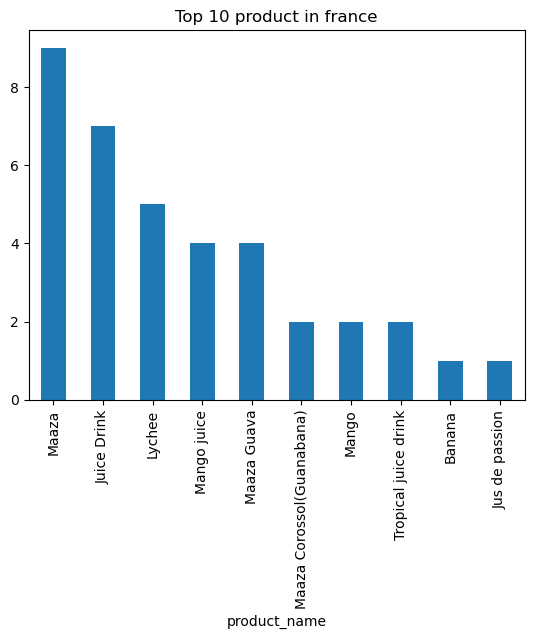

In [40]:
product_graph = france_products.value_counts().head(10).plot(kind="bar",title= ("Top 10 product in france"))
plt.show()


In [41]:
france_data['packaging_tags'].value_counts()

packaging_tags
unknown                        31
plastic, bottle                 3
brick, cardboard                2
bouteille                       1
bouteille-plastique             1
canette-aluminium               1
tetra-pak, brick, cardboard     1
cardboard, paperboard           1
bottle                          1
Name: count, dtype: int64

In [42]:
france_packaging = france_data['packaging_tags'].str.split(",")


exploded_france_packing =france_packaging .explode().str.strip()


In [43]:
france_packaging =exploded_france_packing.replace({
    'brick':'cardboard', 
    'bouteille-plastique':'bottle' , 
    'canette-aluminium':'Aluminium can',
    'tetra-pak':'cardboard',
    'paperboard':'cardboard',
    'plastic':'bottle',
    'bouteille':'bottle'})

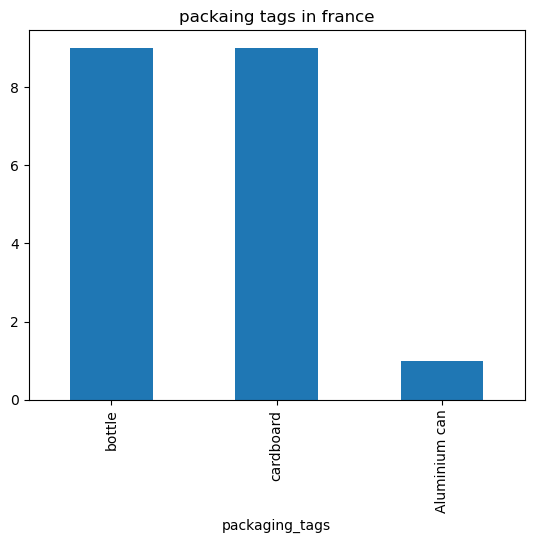

In [44]:
new_packaging = france_packaging[france_packaging != "unknown"]
packaging_count = new_packaging.value_counts()

packaging_count.plot(kind="bar", title="packaing tags in france")
plt.show()

In [45]:
france_purchase_places= france_data['purchase_places'].str.split(",")
exploded =france_purchase_places.explode().str.strip()
exploded


1              unknown
2              unknown
3              unknown
4              unknown
5              unknown
6              unknown
7              unknown
8              unknown
9               France
10             unknown
11             unknown
12             unknown
13             unknown
14       Aubervilliers
14              France
15             unknown
16             unknown
17             unknown
18             unknown
19              France
19                    
20              France
21             unknown
22             unknown
23             unknown
24             unknown
25             unknown
26    Noyelles-Godault
26              France
31             unknown
33             Sénégal
33              France
34             unknown
36             unknown
41             unknown
43             unknown
44             unknown
47             unknown
48             unknown
49             unknown
50             unknown
51             unknown
52             unknown
55         

In [46]:
drop_element= exploded[exploded =='unknown'].index
exploded_places = exploded.drop(drop_element)

In [47]:
drop_element1 = exploded[exploded==""].index
exploded_places = exploded_places.drop(drop_element1)

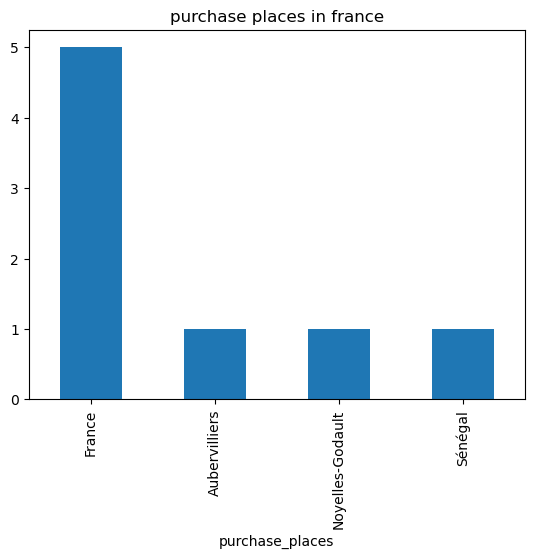

In [48]:
places_count = exploded_places.value_counts()
places_count

places_graph = places_count.plot(kind="bar",title="purchase places in france")
plt.show()

In [50]:
france_data['ecoscore_grade'].value_counts()



ecoscore_grade
unknown    42
Name: count, dtype: int64

### Observation

* Fetched and analyzed france-specific data.
* Standardized similar product name for better analysis.
* Identified the top 10 products in france.
* Cleaned and standardized packaging tags where bottle and cardboard is 9 and remaining values is unknown
* Processed purchase places by spliting values and removing spaces and unknown entries where france appeared 5 times.
* Analyzied nutri-score grade where E:21, C:2, D:1 and remaining values are unknown.
* Eco-score data mostly conatained unknown values in the france data.

# Comparision between france and india

* Product Data: India contains 13 Maaza records, while France has a wider variety of standardized product names.

* Packaging tags: France had some usable packaging information, with bottle and cardboard appearing 9 times each and aluminium can is 1.   India’s packaging data was largely unknown, limiting comparison.

* Purchase Places: France had identifiable purchase-place data, with France appearing 5 times after cleaning. India had mostly unknown values.

* Nutri-Score: France had E: 21, C: 2, and D: 1, with the remaining values unknown. Comparable Nutri-Score information for India was limited where unknown:10, e:7, c,d:1.

* Eco-Score: France’s Eco-Score data was mostly unknown i.e 42, while India also had insufficient data for meaningful comparison where a:1 remaining is unknown.

* Store: France has 39 unknown values and
,Action                                           1
,AZ sasu 45 rue Heurtault 93300 Aubervilliers     1
,Auchan                                           1
,while india 19 unknown values.

* Overall :
     * France provided more usable information for product, packaging, purchase-place, and Nutri-Score analysis, whereas India had a higher proportion of unknown values, limiting detailed comparison.
     * Some of the above columns like code, categories_tags, nova_group, ingredient_texts, nutriments_sugar_100g, nutriments_energy_kcal_100g and brands were not analyze due to there NaN values.
